In [1]:
import numpy as np
import matplotlib.pyplot as plt
from library.snr import optimal_snr, approx_snr
from library.lisa_psd import  psd_source_approx
import corner
import h5py
import pandas as pd

/home/alice/miniforge3/envs/gwpy_env/lib/python3.12/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1
/home/alice/miniforge3/envs/gwpy_env/lib/python3.12/site-packages/arviz/__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be ba

In [2]:
filepath = "/home/alice/catalog_binaries/catalogue_dwds_with_interaction_for_arianna.h5"

In [3]:
import h5py

with h5py.File(filepath, "r") as f:
    print(list(f.keys()))


['Amplitude', 'EquatorialLatitude', 'EquatorialLongitude', 'Frequency', 'FrequencyDerivative', 'Halos', 'Inclination', 'InitialPhase', 'InitialPrimaryMass', 'InitialSecondaryMass', 'LuminosityDistance', 'Polarization', 'PrimaryMass', 'SecondaryMass', 'Type1', 'Type2', 'xgal', 'ygal', 'zgal']


In [4]:
with h5py.File(filepath, "r") as f:
    def print_structure(name, obj):
        print(name)
    f.visititems(print_structure)
    

Amplitude
EquatorialLatitude
EquatorialLongitude
Frequency
FrequencyDerivative
Halos
Inclination
InitialPhase
InitialPrimaryMass
InitialSecondaryMass
LuminosityDistance
Polarization
PrimaryMass
SecondaryMass
Type1
Type2
xgal
ygal
zgal


for fastGB: it should be everything in the source frame
 frequency (Hz), fdot (Hz**2), amplitude (strain), ecliptic latitude, ecliptic longitude, polarization angle, inclination, initial phase (all inradians)
 T obs (seconds),  N (number of frequency bins to generate waveform, power of 2),  delta_t (sampling time in seconds, usually 5 s)

 GW22FrequencySourceFrame

 GW22FrequencyDerivativeSourceFrame
 Amplitude

 Declination --> ecliptic latitude

 RightAscension --> ecliptic longitude

 PolarisationAngle

 InclinationAngle

 InitialPhase

In [3]:
keys = ["Frequency", "FrequencyDerivative", "Amplitude", "Polarization", "EquatorialLatitude", "EquatorialLongitude", "InitialPhase",  "LuminosityDistance", "Inclination", "xgal", "ygal", "zgal", "Type1", "Type2", "Halos"]

with h5py.File(filepath, "r") as f:
    param_binaries = {name: f[name][:] for name in f.keys()}

In [6]:
""" with h5py.File("catalog_subset.h5", "w") as f:
    for key, value in param_binaries.items():
        f.create_dataset(key, data=value) """

' with h5py.File("catalog_subset.h5", "w") as f:\n    for key, value in param_binaries.items():\n        f.create_dataset(key, data=value) '

In [5]:
for key, val in param_binaries.items():
    print(f"{key:35} shape={val.shape}, dtype={val.dtype}")

Frequency                           shape=(15227600, 1), dtype=float64
FrequencyDerivative                 shape=(15227600, 1), dtype=float64
Amplitude                           shape=(15227600, 1), dtype=float64
Polarization                        shape=(15227600, 1), dtype=float64
EquatorialLatitude                  shape=(15227600, 1), dtype=float64
EquatorialLongitude                 shape=(15227600, 1), dtype=float64
InitialPhase                        shape=(15227600, 1), dtype=float64
LuminosityDistance                  shape=(15227600, 1), dtype=float64
Inclination                         shape=(15227600, 1), dtype=float64
xgal                                shape=(15227600, 1), dtype=float64
ygal                                shape=(15227600, 1), dtype=float64
zgal                                shape=(15227600, 1), dtype=float64
Type1                               shape=(15227600, 1), dtype=float64
Type2                               shape=(15227600, 1), dtype=float64
Halos 

Plot some distribution of the parameters of the binaries

In [7]:
output_file = "catalogue_dwds_no_halo.h5"

halo = np.array(param_binaries["Halos"])
mask_halo = (halo == 0)

with h5py.File(filepath, "r") as f_in, h5py.File(output_file, "w") as f_out:
    for key in f_in:
        f_out[key] = f_in[key][:][mask_halo]

In [7]:
with h5py.File("catalogue_dwds_no_halo.h5","r") as f:
    freq = f["Frequency"][:]
    print("N sources:", len(freq))
    print("Min freq:", np.min(freq))
    print("Max freq:", np.max(freq))
    print("Unique spacing:", np.diff(np.sort(freq))[:10])

N sources: 14427706
Min freq: 0.00010039163640238402
Max freq: 0.014652051722155812
Unique spacing: [1.96958173e-10 2.22294533e-09 1.28858496e-09 3.93040048e-10
 7.25895284e-09 2.66498926e-10 3.14917656e-09 5.96596211e-09
 1.08295626e-09 2.29692377e-09]


In [6]:
freqs[0:10]

array([0.00012649, 0.00054326, 0.00095416, 0.00040454, 0.00049502,
       0.00058893, 0.0001899 , 0.00049725, 0.00061057, 0.00056043])

0.05425886113245308 306.9718160310257


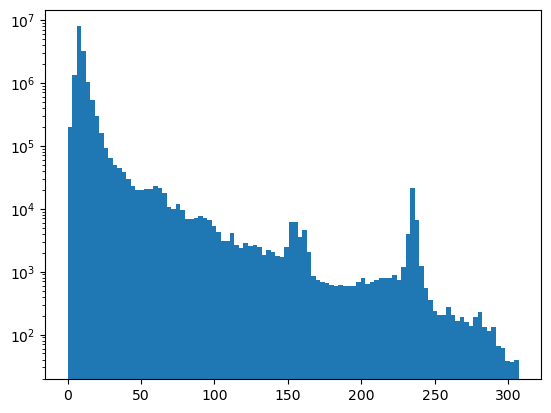

In [12]:
print(param_binaries["LuminosityDistance"].min(), param_binaries["LuminosityDistance"].max())
plt.hist(param_binaries["LuminosityDistance"],  bins =100)
plt.yscale('log')
plt.show()

In [7]:
x = param_binaries['xgal']
y = param_binaries['ygal']
z = param_binaries['zgal']
print(np.min(x), np.max(x))
print(np.min(y), np.max(y))
print(np.min(z), np.max(z))

-297.31633520677957 291.93084775340725
-292.05336582715796 294.2662594191539
-284.45428488171507 295.09174054516234


In [8]:
print(param_binaries["LuminosityDistance"][0:10])

[[13.67121624]
 [13.55324881]
 [13.64271026]
 [13.59082522]
 [13.61697743]
 [13.57053579]
 [13.48718256]
 [13.33454399]
 [13.28079256]
 [13.16915054]]


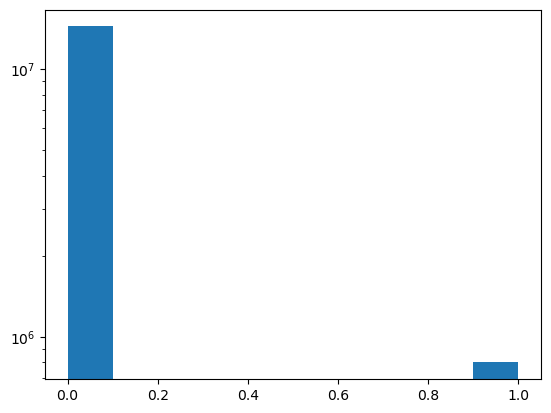

In [9]:
plt.hist(param_binaries["Halos"])
plt.yscale('log')

(array([ 4361160.,        0.,        0.,        0.,        0., 10636017.,
               0.,        0.,        0.,   230423.]),
 array([10. , 10.2, 10.4, 10.6, 10.8, 11. , 11.2, 11.4, 11.6, 11.8, 12. ]),
 <BarContainer object of 10 artists>)

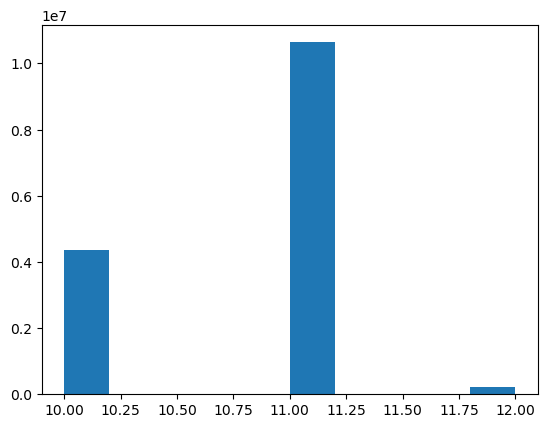

In [10]:
plt.hist(param_binaries["Type1"])

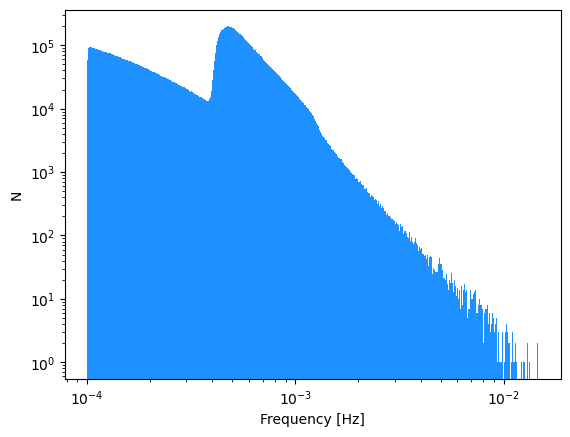

In [4]:
bins = np.logspace(np.log10(param_binaries["Frequency"].min()), np.log10(param_binaries["Frequency"].max()), 500)
plt.hist(param_binaries["Frequency"], bins=bins, color='dodgerblue')
plt.yscale("log")
plt.xlabel('Frequency [Hz]')
plt.ylabel('N')
plt.xscale("log")
#plt.grid(axis = 'y',color='lightgrey')

Min M: 0.032058866861299135
Max M: 1.0043029705066833


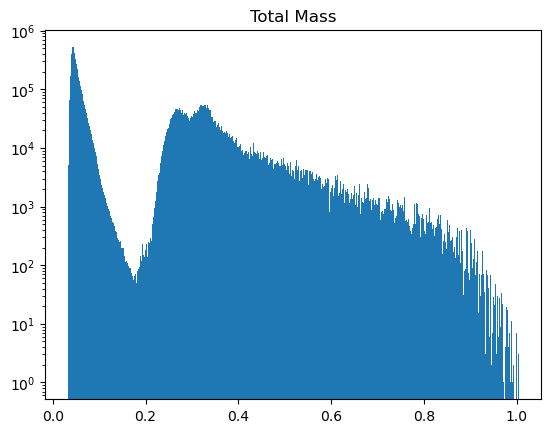

In [ ]:
plt.hist(param_binaries["ChirpMassSSBFrame"], bins=1000)
plt.yscale("log")
plt.title("Chirp Mass")
#plt.xscale("log")
print("Min M:", np.min(param_binaries["ChirpMassSSBFrame"]))
print("Max M:", np.max(param_binaries["ChirpMassSSBFrame"]))

Text(0.5, 1.0, 'Amplitude')

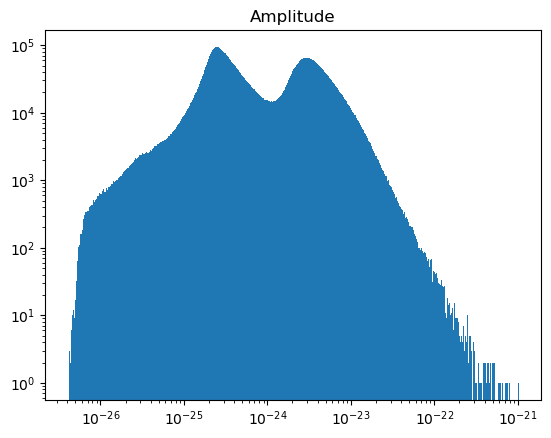

In [14]:
bins = np.logspace(np.log10(param_binaries["Amplitude"].min()), np.log10(param_binaries["Amplitude"].max()), 1000)
plt.hist(param_binaries["Amplitude"], bins = bins)
plt.yscale("log")
plt.xscale("log")
plt.title("Amplitude")
#plt.grid(axis = 'y',color='lightgrey')

-2.0755906766347622e-13
9.734087625455429e-14
3.0489994391803046e-15
Most populated bin index: 68
Count: 15227469.0 99.99913971998214 % of all sources
Bin range: -2.271057992154808e-16 to 2.821893639964824e-15


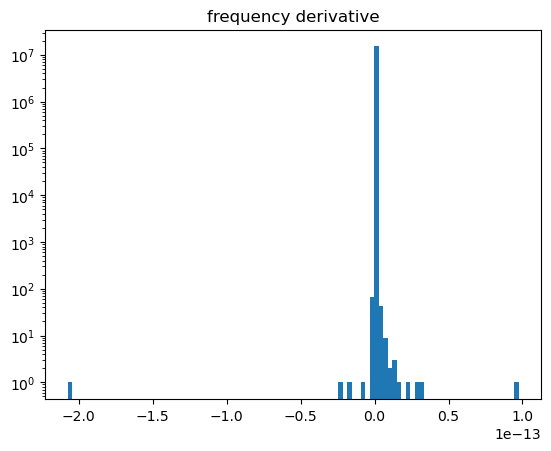

In [15]:
counts, bin_edges, patches = plt.hist(param_binaries["FrequencyDerivative"], bins=100)
plt.yscale("log")
plt.title("frequency derivative")
#plt.grid(axis = 'y',color='lightgrey')
#print(counts)

print(param_binaries["FrequencyDerivative"].min())

print(param_binaries["FrequencyDerivative"].max())

bin_widths = bin_edges[1] - bin_edges[0]
print(bin_widths)
max_bin_index = np.argmax(counts)
print("Most populated bin index:", max_bin_index)
print("Count:", counts[max_bin_index], counts[max_bin_index]/len(param_binaries["Amplitude"])*100, "% of all sources")
print("Bin range:",
      bin_edges[max_bin_index],
      "to",
      bin_edges[max_bin_index + 1])


## Parameters distributions

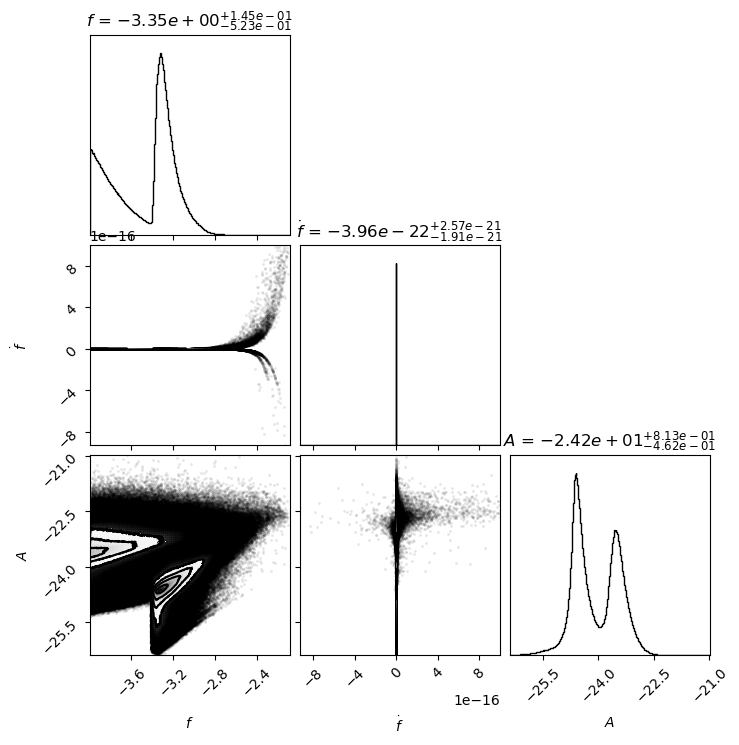

In [15]:
import corner

# F, fdot, A

fdot_min, fdot_max = -1e-15, 1e-15
mask = ((param_binaries["FrequencyDerivative"] > fdot_min) &  (param_binaries["FrequencyDerivative"] < fdot_max))

samples = np.vstack([
    np.log10(param_binaries["Frequency"][mask]),
    param_binaries["FrequencyDerivative"][mask],
    np.log10(param_binaries["Amplitude"][mask])
]).T


#labels = [r"$f$", r"$A$"]
labels = [r"$f$", r"$\dot{f}$", r"$A$"]
ranges = [
    (-3.8, -2.4),          
    (-10e-18, 10e-18),               
    (-25.5, -21.0)         
]

fig = corner.corner(
    samples,
    labels=labels,
    bins=500,
    smooth=0.3,
    plot_density=True,
    plot_contours=True,
    fill_contours=False,
    show_titles=True,
    title_fmt=".2e",
    color="black",
    alpha=0.5,
    label='all sources'
)

plt.show()


In [7]:
len(param_binaries["ChirpMassSSBFrame"])

15539324

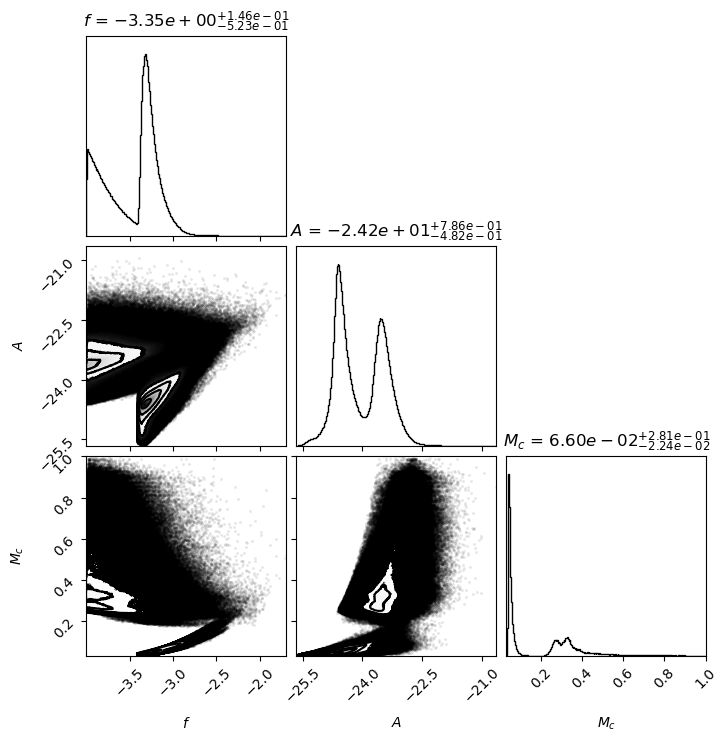

In [5]:
# dist, f, ampl

fdot_min, fdot_max = -1e-15, 1e-15
mask = ((param_binaries["GW22FrequencyDerivativeSourceFrame"] > fdot_min) &  (param_binaries["GW22FrequencyDerivativeSourceFrame"] < fdot_max))

samples = np.vstack([
    np.log10(param_binaries["GW22FrequencySourceFrame"]),
    #param_binaries["GW22FrequencyDerivativeSourceFrame"][mask],
    #param_binaries["LuminosityDistance"],
    np.log10(param_binaries["Amplitude"]),
    param_binaries["ChirpMassSSBFrame"]
]).T

#labels = [r"$f$", r"$\dot{f}$", r"$d_L$"]
#labels = [r"$f$",  r"$d_L$", r"$A$"]
labels = [r"$f$",  r"$A$", r"$M_c$"]
ranges = [
    (-3.8, -2.4),          
    (-10e-18, 10e-18),               
    (-25.5, -21.0)         
]

fig = corner.corner(
    samples,
    labels=labels,
    bins=500,
    smooth=0.3,
    plot_density=True,
    plot_contours=True,
    fill_contours=False,
    show_titles=True,
    title_fmt=".2e",
    color="black",
    alpha=0.5
)

plt.show()


In [11]:
T_obs = 4*365*24*3600
fdots = param_binaries["GW22FrequencyDerivativeSourceFrame"][4000:5000]
deltafs = np.maximum(1/T_obs, np.abs(fdots)*T_obs)
deltaf = 0.1e-13 *T_obs
required_bins = deltafs *T_obs
#print(required_bins)


In [12]:
from library.lisa_response_fastGB import tdi_AE_fastGB
from library.lisa_psd import noise_psd_AE
import scipy.constants as constants

Rough estimate of the psd of a source:

Maggiore (eq. 7.9): $\frac{1}{2} S_h T_{obs} = \langle | \tilde{h(f)}|^2 \rangle $

$ \tilde{h(f)} =  R(f) \tilde{h(f)}$

LISA response (Robson et al. eq. 9): $ R(f) = \frac{3}{20} \frac{1}{(1 + 0.6(f/f_\ast)^2)} $, $ f_\ast  = c/(2 \pi L)$

Source PSD (Robson et al. eq. 16): $ \langle | \tilde{h(f)}|^2 \rangle = 4/5 R(f) A^2(f) $

$ S_h = 2 \Delta f \frac{4}{5} R(f) A^2(f) $

Other option (Robson et al. eq. 19): $ S_h(f) = A^2(f)/(2T_{obs}) $

Check how close the approximate SNR and PSD estimation are to the actual values computed from waveform 

SNR approximate: 1.5188678699137458e-05
SNR accurate: 0.0006107223195475251


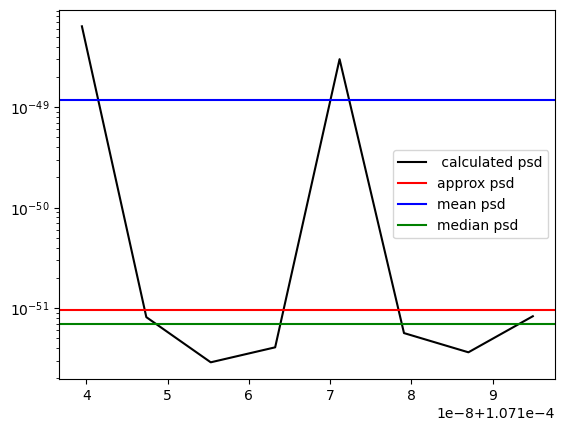

In [13]:
i = 0
f0 = param_binaries["GW22FrequencySourceFrame"][i]
amp = param_binaries["Amplitude"][i]
T_obs = 4*365*24*3600
A, E, kmin, freqs = tdi_AE_fastGB(f0, param_binaries["GW22FrequencyDerivativeSourceFrame"][i], amp, param_binaries["EclipticLatitude"][i], param_binaries["EclipticLongitude"][i], param_binaries["PolarisationAngle"][i], param_binaries["InclinationAngle"][i], 0, 4*365*24*3600, 8, 5)

hc_appr = np.sqrt(16/5 * T_obs) * f0 * amp
snr_appr = approx_snr(hc_appr, f0)

snr_calc = optimal_snr(A, noise_psd_AE(freqs, L = 2.5e9/constants.c, tdi=1.5), T_obs)

print("SNR approximate:", snr_appr)
print("SNR accurate:", snr_calc)

def power_spectrum_calc(h, f):
    if h is None or f is None:
        return None
    h = np.asarray(h)
    f = np.asarray(f)
    df = f[1] - f[0]
    psd = np.abs(h)**2 *df
    if len(h) > 1:
        psd[1:-1] *= 2
    return psd

psd_approx = psd_source_approx(hc_appr, f0, 1.5)
psd_calc = power_spectrum_calc(A, freqs)
psd_calc_mean = np.mean(psd_calc[0])
psd_calc_median = np.median(psd_calc[0])

plt.plot(freqs, psd_calc[0], color='black',label = ' calculated psd')
plt.axhline(psd_approx, color = 'red', label = 'approx psd')
plt.axhline(psd_calc_mean, color = 'blue', label = 'mean psd')
plt.axhline(psd_calc_median, color= 'green', label = 'median psd')
plt.yscale('log')
plt.legend()
plt.show()

In [14]:
T_obs = 4 * 365 * 24 * 3600  
L = 2.5e9 / constants.c               
tdi_param = 1.5               
N = 100000 
indices = np.arange(N)

snr_appr_list = []
snr_calc_list = []

for i in indices:
    f0 = param_binaries["GW22FrequencySourceFrame"][i]
    fdot = param_binaries["GW22FrequencyDerivativeSourceFrame"][i]
    amp = param_binaries["Amplitude"][i]
    lat = param_binaries["EclipticLatitude"][i]
    lon = param_binaries["EclipticLongitude"][i]
    psi = param_binaries["PolarisationAngle"][i]
    inc = param_binaries["InclinationAngle"][i]

    phi0 =  np.random.uniform(0, 2*np.pi)
    A, E, kmin, freqs = tdi_AE_fastGB(
        f0, fdot, amp, lat, lon, psi, inc,phi0, T_obs, 8, 5
    )

    hc_appr = np.sqrt(16 / 5 * T_obs) * f0 * amp
    snr_appr = approx_snr(hc_appr, f0)

    psd_vals = noise_psd_AE(freqs, L=L, tdi=tdi_param)
    snr_calc = optimal_snr(A, psd_vals, T_obs)

    snr_appr_list.append(snr_appr)
    snr_calc_list.append(snr_calc)

snr_appr_list = np.array(snr_appr_list)
snr_calc_list = np.array(snr_calc_list)

ratios = snr_appr_list / snr_calc_list

print("Approx SNR: min {:.6f}, max {:.6f}, mean {:.6f}".format(
    snr_appr_list.min(), snr_appr_list.max(), snr_appr_list.mean()))
print("Accurate SNR: min {:.6f}, max {:.6f}, mean {:.6f}".format(
    snr_calc_list.min(), snr_calc_list.max(), snr_calc_list.mean()))
print("SNR ratio (approx/accurate): min {:.6f}, max {:.6f}, mean {:.6f}".format(
    ratios.min(), ratios.max(), ratios.mean()))

Approx SNR: min 0.000002, max 4.570208, mean 0.002612
Accurate SNR: min 0.000029, max 22.252077, mean 0.023880
SNR ratio (approx/accurate): min 0.007256, max 2.786055, mean 0.076157


Process catalog and store file

In [15]:
N_sources = 1000000
output_filename = "binaries_test_all_SNR_selection"
T_obs = 4*365*24*3600
tdi = 1.5
snr_preselection = 0.01

catalog_test = {
    key: val[:]   
    for key, val in param_binaries.items()
}

from library.catalog_handling import process_catalog_batches
process_catalog_batches(catalog_test, T_obs=T_obs, delta_t=5,tdi = tdi, batch_size=1000, snr_preselection=snr_preselection, output_file=output_filename)

Processing 15539324 sources
Batches: 15540 batches with 1000 sources


Processing batches:   1%|          | 182/15540 [00:00<00:08, 1815.98it/s]


Batch 1/15540: sources [0:1000]
Loud sources (SNR > 0.01): 25
Weak sources (SNR <= 0.01): 975

Batch 2/15540: sources [1000:2000]
Loud sources (SNR > 0.01): 27
Weak sources (SNR <= 0.01): 973

Batch 3/15540: sources [2000:3000]
Loud sources (SNR > 0.01): 24
Weak sources (SNR <= 0.01): 976

Batch 4/15540: sources [3000:4000]
Loud sources (SNR > 0.01): 30
Weak sources (SNR <= 0.01): 970

Batch 5/15540: sources [4000:5000]
Loud sources (SNR > 0.01): 23
Weak sources (SNR <= 0.01): 977

Batch 6/15540: sources [5000:6000]
Loud sources (SNR > 0.01): 17
Weak sources (SNR <= 0.01): 983

Batch 7/15540: sources [6000:7000]
Loud sources (SNR > 0.01): 25
Weak sources (SNR <= 0.01): 975

Batch 8/15540: sources [7000:8000]
Loud sources (SNR > 0.01): 25
Weak sources (SNR <= 0.01): 975

Batch 9/15540: sources [8000:9000]
Loud sources (SNR > 0.01): 13
Weak sources (SNR <= 0.01): 987

Batch 10/15540: sources [9000:10000]
Loud sources (SNR > 0.01): 33
Weak sources (SNR <= 0.01): 967

Batch 11/15540: sour

Processing batches:   4%|▎         | 568/15540 [00:00<00:07, 1894.31it/s]

Loud sources (SNR > 0.01): 31
Weak sources (SNR <= 0.01): 969

Batch 365/15540: sources [364000:365000]
Loud sources (SNR > 0.01): 25
Weak sources (SNR <= 0.01): 975

Batch 366/15540: sources [365000:366000]
Loud sources (SNR > 0.01): 28
Weak sources (SNR <= 0.01): 972

Batch 367/15540: sources [366000:367000]
Loud sources (SNR > 0.01): 23
Weak sources (SNR <= 0.01): 977

Batch 368/15540: sources [367000:368000]
Loud sources (SNR > 0.01): 29
Weak sources (SNR <= 0.01): 971

Batch 369/15540: sources [368000:369000]
Loud sources (SNR > 0.01): 41
Weak sources (SNR <= 0.01): 959

Batch 370/15540: sources [369000:370000]
Loud sources (SNR > 0.01): 60
Weak sources (SNR <= 0.01): 940

Batch 371/15540: sources [370000:371000]
Loud sources (SNR > 0.01): 34
Weak sources (SNR <= 0.01): 966

Batch 372/15540: sources [371000:372000]
Loud sources (SNR > 0.01): 33
Weak sources (SNR <= 0.01): 967

Batch 373/15540: sources [372000:373000]
Loud sources (SNR > 0.01): 14
Weak sources (SNR <= 0.01): 986

B

...

Processing batches:  99%|█████████▉| 15410/15540 [00:12<00:00, 1305.54it/s]

Loud sources (SNR > 0.01): 14
Weak sources (SNR <= 0.01): 986

Batch 15402/15540: sources [15401000:15402000]
Loud sources (SNR > 0.01): 23
Weak sources (SNR <= 0.01): 977

Batch 15403/15540: sources [15402000:15403000]
Loud sources (SNR > 0.01): 14
Weak sources (SNR <= 0.01): 986

Batch 15404/15540: sources [15403000:15404000]
Loud sources (SNR > 0.01): 14
Weak sources (SNR <= 0.01): 986

Batch 15405/15540: sources [15404000:15405000]
Loud sources (SNR > 0.01): 14
Weak sources (SNR <= 0.01): 986

Batch 15406/15540: sources [15405000:15406000]
Loud sources (SNR > 0.01): 23
Weak sources (SNR <= 0.01): 977

Batch 15407/15540: sources [15406000:15407000]
Loud sources (SNR > 0.01): 21
Weak sources (SNR <= 0.01): 979

Batch 15408/15540: sources [15407000:15408000]
Loud sources (SNR > 0.01): 22
Weak sources (SNR <= 0.01): 978

Batch 15409/15540: sources [15408000:15409000]
Loud sources (SNR > 0.01): 29
Weak sources (SNR <= 0.01): 971

Batch 15410/15540: sources [15409000:15410000]
Loud sourc

Processing batches: 100%|██████████| 15540/15540 [00:12<00:00, 1249.45it/s]

Loud sources (SNR > 0.01): 22
Weak sources (SNR <= 0.01): 978

Batch 15418/15540: sources [15417000:15418000]
Loud sources (SNR > 0.01): 21
Weak sources (SNR <= 0.01): 979

Batch 15419/15540: sources [15418000:15419000]
Loud sources (SNR > 0.01): 20
Weak sources (SNR <= 0.01): 980

Batch 15420/15540: sources [15419000:15420000]
Loud sources (SNR > 0.01): 7
Weak sources (SNR <= 0.01): 993

Batch 15421/15540: sources [15420000:15421000]
Loud sources (SNR > 0.01): 17
Weak sources (SNR <= 0.01): 983

Batch 15422/15540: sources [15421000:15422000]
Loud sources (SNR > 0.01): 21
Weak sources (SNR <= 0.01): 979

Batch 15423/15540: sources [15422000:15423000]
Loud sources (SNR > 0.01): 20
Weak sources (SNR <= 0.01): 980

Batch 15424/15540: sources [15423000:15424000]
Loud sources (SNR > 0.01): 20
Weak sources (SNR <= 0.01): 980

Batch 15425/15540: sources [15424000:15425000]
Loud sources (SNR > 0.01): 11
Weak sources (SNR <= 0.01): 989

Batch 15426/15540: sources [15425000:15426000]
Loud source

'binaries_test_all_SNR_selection'